In [229]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [230]:
df = pd.read_csv('/content/Student Social Media And Mental Health Impact.csv')
df.head()

,Age,Gender,Country,Academic_Level,Most_Used_Platform,Purpose_Of_Use,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Stress_Level,Mental_Health_Score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4


In [231]:
df.shape

(5000, 13)

In [232]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 13 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      5000 non-null   int64  
 1   Gender                   5000 non-null   object 
 2   Country                  5000 non-null   object 
 3   Academic_Level           5000 non-null   object 
 4   Most_Used_Platform       5000 non-null   object 
 5   Purpose_Of_Use           5000 non-null   object 
 6   Avg_Daily_Usage_Hours    5000 non-null   float64
 7   Daily_Unlocks            5000 non-null   int64  
 8   Study_Hours              5000 non-null   float64
 9   Physical_Activity_Hours  5000 non-null   float64
 10  Sleep_Hours_Per_Night    5000 non-null   float64
 11  Stress_Level             5000 non-null   object 
 12  Mental_Health_Score      5000 non-null   float64
dtypes: float64(5), int64(2), object(6)
memory usage: 507.9+ KB


In [233]:
df.describe()

,Age,Avg_Daily_Usage_Hours,Daily_Unlocks,Study_Hours,Physical_Activity_Hours,Sleep_Hours_Per_Night,Mental_Health_Score
count,5000.00000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,20.82180,5.078460,171.452600,3.008420,1.751000,6.634580,6.230980
std,1.73662,1.653913,42.858254,1.637018,0.668398,1.221391,1.278701
min,18.00000,1.000000,62.000000,0.300000,-0.400000,3.600000,3.600000
25%,19.00000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.00000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.00000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.00000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


In [234]:
df.columns = df.columns.str.lower()

In [235]:
num_cols = [col for col in df.columns if df[col].dtype != 'object']
cat_cols = [col for col in df.columns if df[col].dtype == 'object']

In [236]:
df.head(4)

,age,gender,country,academic_level,most_used_platform,purpose_of_use,avg_daily_usage_hours,daily_unlocks,study_hours,physical_activity_hours,sleep_hours_per_night,stress_level,mental_health_score
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3


In [237]:
df.isna().sum()

,0
age,0
gender,0
country,0
academic_level,0
most_used_platform,0
purpose_of_use,0
avg_daily_usage_hours,0
daily_unlocks,0
study_hours,0
physical_activity_hours,0


In [238]:
df.duplicated().sum()

np.int64(2)

In [239]:
df = df.drop_duplicates()

In [240]:
df.shape

(4998, 13)

<Axes: xlabel='mental_health_score', ylabel='Count'>

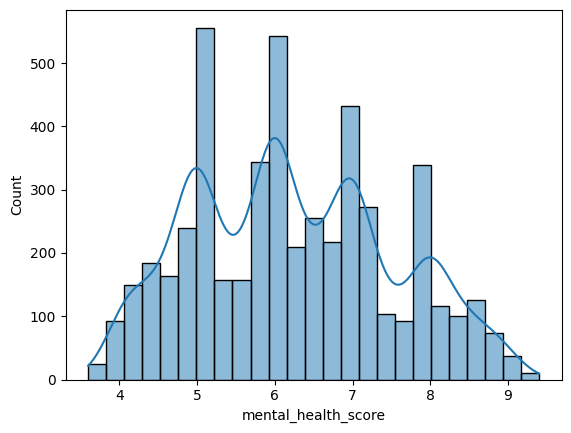

In [241]:
sns.histplot(df['mental_health_score'], kde = True)

<Axes: >

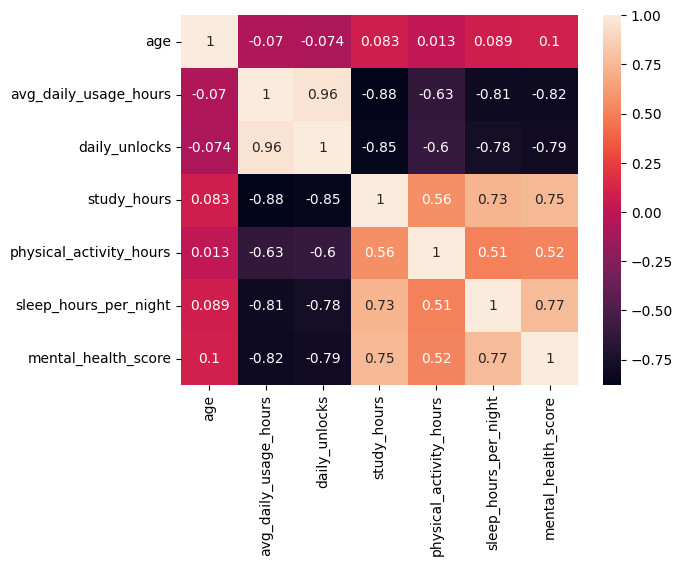

In [242]:
sns.heatmap(df.corr(numeric_only = True), annot = True)

<Axes: xlabel='stress_level', ylabel='mental_health_score'>

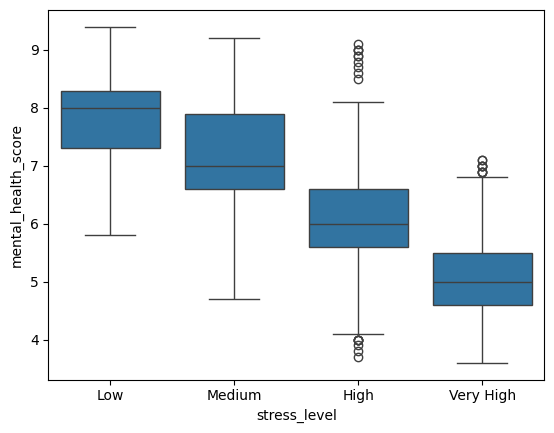

In [243]:
order = ['Low', "Medium", "High", "Very High"]
sns.boxplot(data = df, x = 'stress_level', y = 'mental_health_score', order = order)

In [244]:
df.columns

Index(['age', 'gender', 'country', 'academic_level', 'most_used_platform',
       'purpose_of_use', 'avg_daily_usage_hours', 'daily_unlocks',
       'study_hours', 'physical_activity_hours', 'sleep_hours_per_night',
       'stress_level', 'mental_health_score'],
      dtype='object')

<Axes: xlabel='sleep_hours_per_night', ylabel='mental_health_score'>

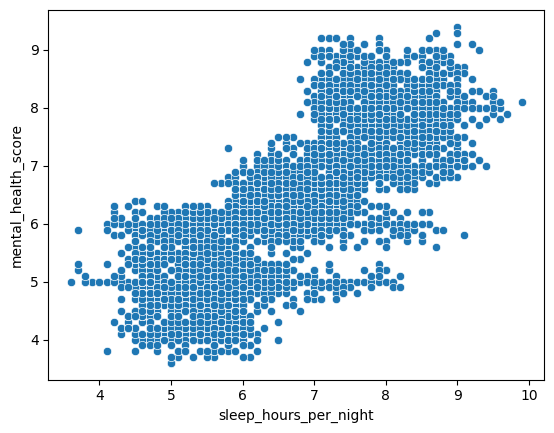

In [245]:
sns.scatterplot(data = df, x = 'sleep_hours_per_night', y = 'mental_health_score')

<Axes: xlabel='avg_daily_usage_hours', ylabel='mental_health_score'>

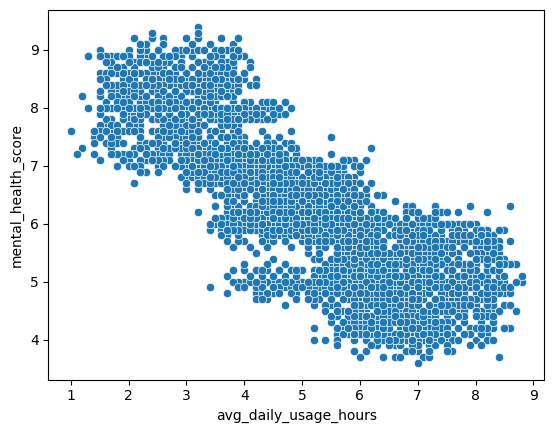

In [246]:
sns.scatterplot(data = df, x = 'avg_daily_usage_hours', y = 'mental_health_score')

<Axes: xlabel='most_used_platform', ylabel='count'>

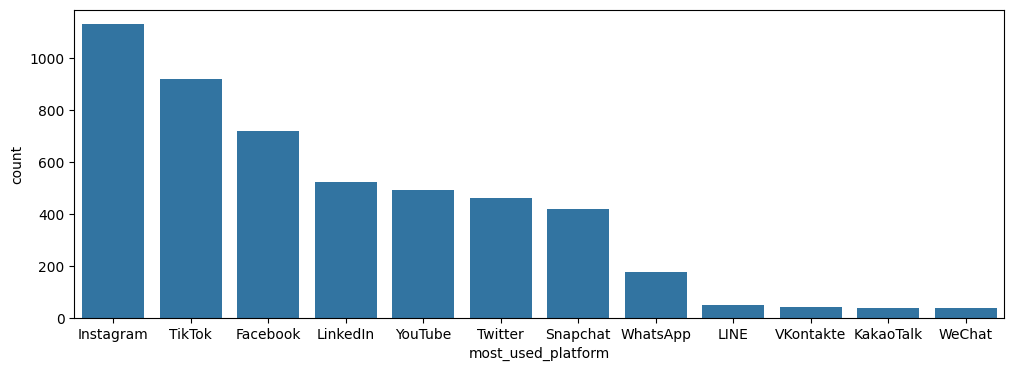

In [247]:
plt.figure(figsize = (12, 4))
sns.countplot(data=df, x= 'most_used_platform',
              order = df['most_used_platform'].value_counts().index )

In [248]:
num_features = df.select_dtypes(include = 'number')
Q1 = num_features.quantile(0.25)
Q3 = num_features.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outliers = (num_features < lower_bound) | (num_features > upper_bound)
outliers.sum()


,0
age,0
avg_daily_usage_hours,0
daily_unlocks,0
study_hours,2
physical_activity_hours,22
sleep_hours_per_night,0
mental_health_score,0


## Data Cleaning

In [249]:
df = df.drop_duplicates()

In [250]:
df['physical_activity_hours'] = df['physical_activity_hours'].clip(lower=0)

In [251]:
df.describe()

,age,avg_daily_usage_hours,daily_unlocks,study_hours,physical_activity_hours,sleep_hours_per_night,mental_health_score
count,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000,4998.000000
mean,20.822129,5.078491,171.455582,3.008403,1.751160,6.634654,6.231152
std,1.736774,1.654097,42.859829,1.636831,0.667282,1.221561,1.278476
min,18.000000,1.000000,62.000000,0.300000,0.000000,3.600000,3.600000
25%,19.000000,3.800000,140.000000,1.500000,1.300000,5.600000,5.100000
50%,21.000000,5.000000,171.000000,2.800000,1.700000,6.600000,6.100000
75%,22.000000,6.300000,204.000000,4.200000,2.200000,7.500000,7.100000
max,24.000000,8.800000,273.000000,8.300000,4.100000,9.900000,9.400000


### Skewness

In [252]:
num_features.skew()

,0
age,0.155008
avg_daily_usage_hours,0.005575
daily_unlocks,0.002309
study_hours,0.436125
physical_activity_hours,0.040623
sleep_hours_per_night,0.123919
mental_health_score,0.207086


In [253]:
top_countries = df['country'].value_counts().index[:10].tolist()

In [254]:
def group_countries(country):
  if country in top_countries:
    return country
  else:
    return 'Other'

In [255]:
df['grouped_country'] = df['country'].apply(group_countries)

In [256]:
df.columns

Index(['age', 'gender', 'country', 'academic_level', 'most_used_platform',
       'purpose_of_use', 'avg_daily_usage_hours', 'daily_unlocks',
       'study_hours', 'physical_activity_hours', 'sleep_hours_per_night',
       'stress_level', 'mental_health_score', 'grouped_country'],
      dtype='object')

In [257]:
df['grouped_country'].value_counts()

,count
grouped_country,
Other,3231
India,389
USA,354
Canada,230
Australia,198
UK,185
Germany,136
Mexico,94
Turkey,94


In [258]:
df.head()

,age,gender,country,academic_level,most_used_platform,purpose_of_use,avg_daily_usage_hours,daily_unlocks,study_hours,physical_activity_hours,sleep_hours_per_night,stress_level,mental_health_score,grouped_country
0,21,Male,Other,Undergraduate,Facebook,Networking,4.0,134,4.5,2.2,6.7,Medium,6.8,Other
1,23,Female,Other,Graduate,LinkedIn,Education,1.6,73,7.0,2.4,8.6,Low,7.6,Other
2,22,Male,Canada,Undergraduate,Instagram,Entertainment,4.6,166,4.0,1.8,6.7,Medium,7.0,Canada
3,18,Male,Other,High School,Snapchat,Entertainment,7.0,220,1.0,1.7,5.4,Very High,5.3,Other
4,24,Female,Other,Graduate,Facebook,Networking,7.5,237,1.0,1.1,5.0,Very High,4.4,Other


In [259]:
skewed_col = ['study_hours']
other_numeric_cols = ['age',
 'avg_daily_usage_hours',
 'daily_unlocks',
 'physical_activity_hours',
 'sleep_hours_per_night']
ordinal_col = ['stress_level']
normal_col = ['gender',
 'grouped_country',
 'academic_level',
 'most_used_platform',
 'purpose_of_use']
feature_col = skewed_col + other_numeric_cols + normal_col + ordinal_col

In [260]:
X = df[feature_col]
y = df['mental_health_score']

In [261]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state = 42)

In [262]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import (FunctionTransformer,
                                   StandardScaler, OrdinalEncoder,
                                   OneHotEncoder)
from sklearn.compose import ColumnTransformer

#1. skew pipeline
skew_pipeline = Pipeline(steps=[
    ('log_transform', FunctionTransformer(np.log1p)),
    ('scale', StandardScaler())
])

#2. Numeric Features
plain_numeric_pipeline = Pipeline(steps=[
    ('scale', StandardScaler())
])

#3. Ordinal Feature
ordinal_pipeline = Pipeline(steps =[
    ('encode', OrdinalEncoder(categories =[ ["Low", "Medium", "High", "Very High"]]))
])

#4. Nominal Features
nominal_pipeline = Pipeline(steps = [
    ('encode', OneHotEncoder(handle_unknown= 'ignore'))
])

# Column Transformer
preprocessor = ColumnTransformer(transformers=[
    ("Skewed Pipeline", skew_pipeline, skewed_col),
    ("Plain Numeric", plain_numeric_pipeline, other_numeric_cols),
    ("Ordinal", ordinal_pipeline, ordinal_col),
    ("Nominal", nominal_pipeline, normal_col)
])

In [263]:
preprocessor

ColumnTransformer(transformers=[('Skewed Pipeline',
                                 Pipeline(steps=[('log_transform',
                                                  FunctionTransformer(func=<ufunc 'log1p'>)),
                                                 ('scale', StandardScaler())]),
                                 ['study_hours']),
                                ('Plain Numeric',
                                 Pipeline(steps=[('scale', StandardScaler())]),
                                 ['age', 'avg_daily_usage_hours',
                                  'daily_unlocks', 'physical_activity_hours',
                                  'sleep_hours_per_night']),
                                ('Ordinal',
                                 Pipeline(steps=[('encode',
                                                  OrdinalEncoder(categories=[['Low',
                                                                              'Medium',
                                                                              'High',
                                                                              'Very '
                                                                              'High']]))]),
                                 ['stress_level']),
                                ('Nominal',
                                 Pipeline(steps=[('encode',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['gender', 'grouped_country', 'academic_level',
                                  'most_used_platform', 'purpose_of_use'])])

# Linear Regression Model

In [268]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

lr_pipeline = Pipeline(steps =[
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])
lr_pipeline.fit(X_train, y_train)
lr_preds_testing = lr_pipeline.predict(X_test)
lr_preds_training = lr_pipeline.predict(X_train)

lr_r2_testing = r2_score(y_test, lr_preds_testing)
lr_r2_training = r2_score(y_train, lr_preds_training)
lr_mae = mean_absolute_error(y_test, lr_preds_testing)

print(f"Accuracy of Training: {lr_r2_training}")
print(f"Accuracy of Testing: {lr_r2_testing}")
print(f'MAE: {lr_mae}')

Accuracy of Training: 0.7236771199387539
Accuracy of Testing: 0.739794461743302
MAE: 0.5361775634720183


## Random Forest Model

In [274]:
from sklearn.ensemble import RandomForestRegressor

rf_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('random forest', RandomForestRegressor())
])

rf_pipeline.fit(X_train, y_train)

rf_preds_testing = rf_pipeline.predict(X_test)
rf_preds_training = rf_pipeline.predict(X_train)
rf_mae = mean_absolute_error(y_test, rf_preds_testing)

rf_r2_training = r2_score(y_train, rf_preds_training)
rf_r2_testing = r2_score(y_test, rf_preds_testing)

print(f"Accuracy of Training: {rf_r2_training}")
print(f"Accuracy of Testing: {rf_r2_testing}")
print(f'MAE: {rf_mae}')



Accuracy of Training: 0.9813411317150674
Accuracy of Testing: 0.8774201835405756
MAE: 0.34743116666666674


# Hyper Parameter Tuning

In [275]:
from sklearn.model_selection import RandomizedSearchCV

param_grid = {
    'random forest__n_estimators'       : [100,200,300],
    'random forest__max_depth'         : [5,10,15],
    'random forest__min_samples_split' : [2,5,10],
    'random forest__min_samples_leaf'  : [1,2,4]
}

random_search = RandomizedSearchCV(
    estimator=rf_pipeline,
    param_distributions=param_grid,
    n_iter = 15,
    cv = 5,
    scoring='r2',
    random_state=42,
    n_jobs =-1 #processor free
)

random_search.fit(X_train, y_train)

RandomizedSearchCV(cv=5,
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('Skewed '
                                                                               'Pipeline',
                                                                               Pipeline(steps=[('log_transform',
                                                                                                FunctionTransformer(func=<ufunc 'log1p'>)),
                                                                                               ('scale',
                                                                                                StandardScaler())]),
                                                                               ['study_hours']),
                                                                              ('Plain '
                                                                               'Numeric',
                                                                               Pipeline(steps=[('scale',
                                                                                                StandardScaler())]),
                                                                               ['age',
                                                                                'avg_daily_usage_hours',
                                                                                'daily_unlocks',
                                                                                '...
                                                                                'grouped_country',
                                                                                'academic_level',
                                                                                'most_used_platform',
                                                                                'purpose_of_use'])])),
                                             ('random forest',
                                              RandomForestRegressor())]),
                   n_iter=15, n_jobs=-1,
                   param_distributions={'random forest__max_depth': [5, 10, 15],
                                        'random forest__min_samples_leaf': [1,
                                                                            2,
                                                                            4],
                                        'random forest__min_samples_split': [2,
                                                                             5,
                                                                             10],
                                        'random forest__n_estimators': [100,
                                                                        200,
                                                                        300]},
                   random_state=42, scoring='r2')

In [276]:
random_search.best_params_

{'random forest__n_estimators': 300,
 'random forest__min_samples_split': 5,
 'random forest__min_samples_leaf': 2,
 'random forest__max_depth': 15}

In [278]:
rf_best_estimator = random_search.best_estimator_
rf_best_preds = rf_best_estimator.predict(X_test)

print(f"R2 Score for random forest after hyperparameter tuning {r2_score(y_test, rf_best_preds)}")
print(f"MAE Score for random forest after hyperparameter tuning {mean_absolute_error(y_test, rf_best_preds)}")

R2 Score for random forest after hyperparameter tuning 0.865276584203506
MAE Score for random forest after hyperparameter tuning 0.36862854224102753


In [280]:

from sklearn.metrics import mean_squared_error

# Calculate RMSE for Linear Regression
lr_rmse = np.sqrt(mean_squared_error(y_test, lr_preds_testing))

# Calculate RMSE for default Random Forest
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds_testing))

# Calculate RMSE for tuned Random Forest
rf_tuned_preds          = random_search.best_estimator_.predict(X_test)
rf_tuned_rmse           = np.sqrt(mean_squared_error(y_test, rf_tuned_preds))
rf_tuned_training_preds = random_search.best_estimator_.predict(X_train)
r2_tuned_training       = r2_score(y_train, rf_tuned_training_preds)
rf_tuned_mae            = mean_absolute_error(y_test, rf_tuned_preds)
rf_tuned_r2             = r2_score(y_test, rf_tuned_preds)

In [281]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest (default)', 'Random Forest (tuned)'],
    'R2': [lr_r2_testing, rf_r2_testing, rf_tuned_r2],
    'Training R2': [lr_r2_training, rf_r2_training, r2_tuned_training],
    'MAE': [lr_mae, rf_mae, rf_tuned_mae],
    'RMSE': [lr_rmse, rf_rmse, rf_tuned_rmse]
})

In [282]:
results

,Model,R2,Training R2,MAE,RMSE
0,Linear Regression,0.739794,0.723677,0.536178,0.676032
1,Random Forest (default),0.877420,0.981341,0.347431,0.464000
2,Random Forest (tuned),0.865277,0.955118,0.368629,0.486441


## Save the file

In [283]:
import joblib
joblib.dump(rf_pipeline, "mental_health_model.pkl")

['mental_health_model.pkl']